In [ ]:
'''
MINI-PROJECT 1: Model Training, and Evaluation 
By:
Dhawal Mehrotra, 25070126060
Bhavya Anup Sharma, 25070126049
'''

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

In [11]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Processed DataFrame.csv", sep=';')
df.head()

,Molecule ChEMBL ID,Molecular Weight,#RO5 Violations,AlogP,Smiles,pChEMBL Value,Ligand Efficiency BEI,Assay Type,Activity_Class,std_Molecular Weight,std_AlogP,std_Ligand Efficiency BEI
0,CHEMBL7927,326.83,0.0,3.31,Clc1ccc(N2CCN(Cc3cnn4ccccc34)CC2)cc1,5.37,16.420000,1,0,0.066335,0.487544,0.178423
1,CHEMBL1078207,458.59,0.0,4.48,O=S(=O)(Nc1ccc2c(c1)CCN(Cc1cc[nH]n1)CC2)c1ccc(...,6.20,13.519702,2,1,0.102051,0.528780,0.146908
2,CHEMBL231546,505.87,2.0,5.60,CN1CCc2cc(Br)c(NS(=O)(=O)c3ccc(-c4ccc(Cl)cc4)c...,7.20,14.230000,1,1,0.114867,0.568254,0.154626
3,CHEMBL231431,444.96,0.0,4.98,CN1CCc2ccc(NS(=O)(=O)c3ccc(-c4ccc(F)c(Cl)c4)cc...,7.30,16.410000,1,1,0.098356,0.546402,0.178315
4,CHEMBL231333,358.51,0.0,3.82,CCCCc1ccc(S(=O)(=O)Nc2ccc3c(c2)CN(C)CC3)cc1,6.40,17.850000,1,1,0.074922,0.505519,0.193962


In [12]:
features = ['std_Molecular Weight', 'std_AlogP', 'std_Ligand Efficiency BEI']
X = df[features]
y = df['Activity_Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

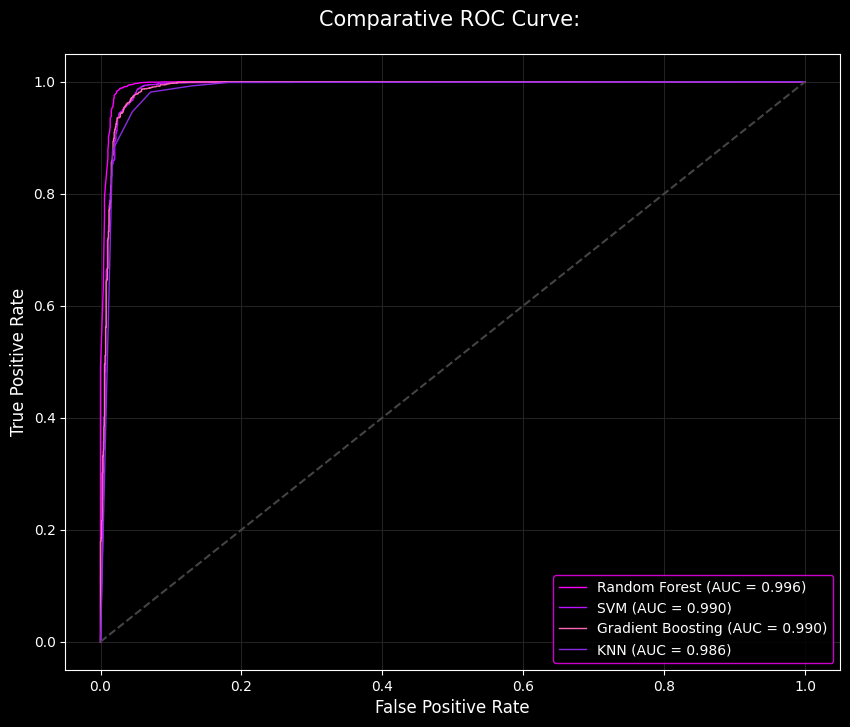

In [13]:
# 3. The Tournament (Baseline Models)
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
cyber_colors = [
    '#FF00FF', # Electric Magenta
    '#BC13FE', # Neon Purple
    '#FF69B4', # Hot Pink
    '#8A2BE2'  # Blue Violet
]

# Iterate through models to establish the baseline leaderboard and plot ROC
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)

    # Use the color from our cyber_colors list
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})',
             color=cyber_colors[i], linewidth=1)
plt.plot([0, 1], [0, 1], color='#444444', linestyle='--') # Muted gray for the baseline
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Comparative ROC Curve: ', fontsize=15, pad=20)
plt.legend(frameon=True, facecolor='black', edgecolor='#FF00FF')
plt.grid(color='#222222')
plt.show()

In [14]:
# 4. The Ascension (Hyperparameter Tuning for the Champion)
# Based on the highest AUC, we tune the Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)
champion_model = grid_search.best_estimator_

print(f"Best Parameters for Champion: {grid_search.best_params_}")

Best Parameters for Champion: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


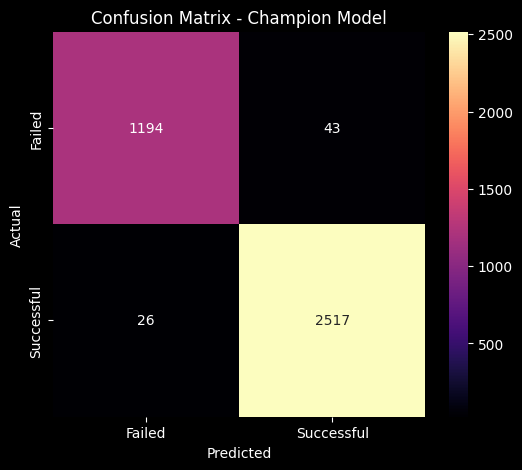

In [15]:
# 5. Visual Insights: Confusion Matrix
y_pred = champion_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=['Failed', 'Successful'], yticklabels=['Failed', 'Successful'])
plt.title('Confusion Matrix - Champion Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_1364\34123397.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')


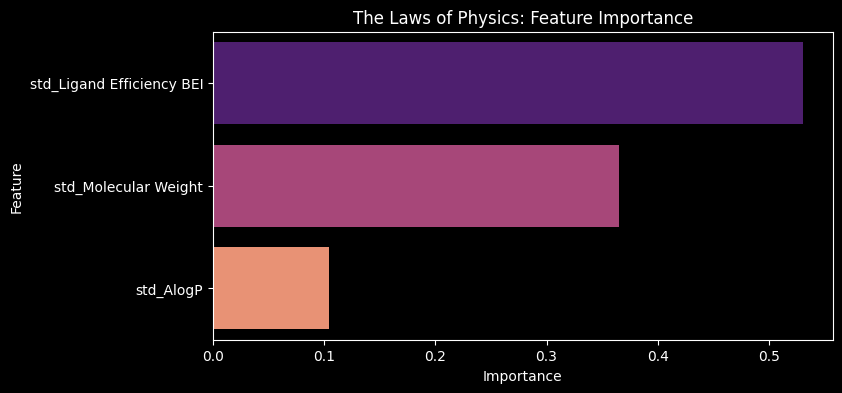

In [16]:
# 6. Laws of Physics (Feature Importance)
importances = champion_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma')
plt.title('The Laws of Physics: Feature Importance')
plt.show()